# The Fannie Mae Loan-Performance Data Bible

**One notebook that documents the entire dataset**: every column's meaning, which columns the model
is allowed to see (and which are held out as leakage), and the headline risk signal — the
**delinquency / default rate by year** across the whole loan book.

It reads a pre-computed statistics artifact so it renders instantly; regenerate that artifact with:

```bash
# representative 4% panel (fast; the deterministic hash sample is unbiased for rates)
python scripts/profile_fannie_dataset.py \
    --panel gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet \
    --out reports/fannie_dataset_profile.json

# OR the TRUE whole loan book, straight from the raw source
python scripts/profile_fannie_dataset.py \
    --raw-root gs://sriram-credit-fm-data/fannie_by_reporting \
    --out reports/fannie_dataset_profile.json --no-vintage
```

**Contents**
1. Setup &amp; overview
2. Column glossary (all 113 source fields + 6 derived)
3. Columns *included* in training vs *excluded* / *leakage*
4. Delinquency &amp; default rate by year
5. Per-column statistics
6. Notes &amp; caveats

## 1. Setup &amp; overview

In [1]:
import importlib.util
import json
from pathlib import Path

import pandas as pd
import yaml

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 100)

# find the repo root (walk up until we see configs/)
ROOT = Path.cwd()
while not (ROOT / "configs" / "fannie_mae").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs" / "fannie_mae").exists(), "run inside the credit-foundation-model repo"

# import the glossary module directly (avoids importing credit_fm/__init__, which pulls in torch)
_gspec = importlib.util.spec_from_file_location(
    "fannie_glossary", ROOT / "src" / "credit_fm" / "data" / "fannie_glossary.py")
G = importlib.util.module_from_spec(_gspec)
_gspec.loader.exec_module(G)

# resolve the ingested-panel output path from the recipe that produced it (config is the truth)
_common = yaml.safe_load((ROOT / "configs" / "fannie_mae" / "common.yaml").read_text())
_ingest = yaml.safe_load((ROOT / "configs" / "fannie_mae" / "ingest_2000_2024.yaml").read_text())
_raw_dir = _common["paths"]["raw"].replace("${gcs_root}", _common["gcs_root"])
PANEL_PATH = f"{_raw_dir}/{_ingest['combined_name']}"

# Load the pre-computed statistics profile. The full profile (`fannie_dataset_profile.json`, with
# per-column stats) drives every section; if it is absent we fall back to the lightweight
# `delinquency_4pct.json` so the overview + delinquency sections still render (only the per-column
# stats in section 5 need the full profile).
FULL_PROFILE = ROOT / "reports" / "fannie_dataset_profile.json"
DLQ_PROFILE = ROOT / "reports" / "delinquency_4pct.json"
if FULL_PROFILE.exists():
    PROFILE = json.loads(FULL_PROFILE.read_text())
    PROFILE_SRC = FULL_PROFILE.name
elif DLQ_PROFILE.exists():
    PROFILE = json.loads(DLQ_PROFILE.read_text())
    PROFILE_SRC = DLQ_PROFILE.name + " (delinquency-only — section 5 needs the full profile)"
else:
    PROFILE = None
    PROFILE_SRC = None
HAS_COLUMN_STATS = bool(PROFILE and PROFILE.get("columns"))
print("glossary fields:", len(G.ALL_FIELDS), "| profile:",
      PROFILE_SRC or "MISSING (run scripts/profile_fannie_dataset.py — see section 4d for commands)")

glossary fields: 119 | profile: fannie_dataset_profile.json


In [2]:
print(f"panel path : {PANEL_PATH}")
if PROFILE:
    print(f"source     : {PROFILE['source']}  ({PROFILE['source_kind']})")
    print(f"generated  : {PROFILE['generated_utc']}")
    print(f"rows       : {PROFILE['n_rows']:,}  (loan-months)")
    print(f"loans      : {PROFILE['n_loans']}")
    print(f"columns    : {PROFILE['n_columns']}  (0 = delinquency-only profile; run a full profile "
          f"for per-column stats)")
    print(f"reporting  : {PROFILE['reporting_range'][0]} .. {PROFILE['reporting_range'][1]}")
    print(f"origination: {PROFILE['origination_range'][0]} .. {PROFILE['origination_range'][1]}")
else:
    print("No profile artifact yet — generate one to populate the overview, delinquency, and "
          "per-column sections (see the commands in section 4d).")

panel path : gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet
source     : gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet  (panel)
generated  : 2026-07-09T02:49:36+00:00
rows       : 125,027,505  (loan-months)
loans      : 2264282
columns    : 118  (0 = delinquency-only profile; run a full profile for per-column stats)
reporting  : 2000-01-31 .. 2024-12-31
origination: 1999-01-31 .. 2024-12-31


## 2. Column glossary

Every field in the dataset, condensed from the official *Single-Family Loan Performance Dataset and
Credit Risk Transfer — Glossary and File Layout* (© 2026 Fannie Mae). `position` is the 1-based
field position in the published layout; the last 6 rows (`position = derived`) are columns our
ingest step adds so the rest of the pipeline stays asset-generic.

In [3]:
def glossary_frame(fields):
    rows = []
    for name, (pos, plain, dtype, desc, enums) in fields.items():
        rows.append({"position": pos if pos is not None else "derived", "column": name,
                     "name": plain, "type": dtype, "description": desc,
                     "enumerations": enums or ""})
    df = pd.DataFrame(rows)
    # raw fields first (by position), derived last
    df["_sort"] = [p if isinstance(p, int) else 10_000 + i for i, p in enumerate(df["position"])]
    return df.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)

GLOSSARY = glossary_frame(G.ALL_FIELDS)
print(f"{len(GLOSSARY)} fields ({len(G.RAW_FIELDS)} source + {len(G.DERIVED_FIELDS)} derived)")
GLOSSARY

119 fields (113 source + 6 derived)


,position,column,name,type,description,enumerations
0,1,reference_pool_id,Reference Pool ID,str,A unique identifier for the reference pool.,
1,2,loan_identifier,Loan Identifier,str,A unique identifier for the mortgage loan (does not correspond to loan identifiers in other Fann...,
2,3,monthly_reporting_period,Monthly Reporting Period,date(MMYYYY),The month/year of the servicer's cut-off period for the loan information (the observation month ...,
3,4,channel,Channel,str,The origination channel used by the party that delivered the loan to the issuer.,R = Retail; C = Correspondent; B = Broker
4,5,seller_name,Seller Name,str,The entity that delivered the mortgage loan to Fannie Mae. Sellers under ~1% of volume are shown...,
5,6,servicer_name,Servicer Name,str,The entity that serves as the primary servicer of the loan. Blank before Dec-2001; small service...,
6,7,master_servicer,Master Servicer,str,Fannie Mae.,
7,8,original_interest_rate,Original Interest Rate,float,The original interest rate on the loan as identified in the original mortgage note.,
8,9,current_interest_rate,Current Interest Rate,float,The rate of interest in effect for the periodic installment due (updated for modified loans).,
9,10,original_upb,Original UPB,float,The dollar amount of the loan as stated on the note at origination (rounded).,


**The 6 derived columns** (labels &amp; keys the pipeline computes) in detail:

In [4]:
glossary_frame(G.DERIVED_FIELDS)

,position,column,name,type,description,enumerations
0,derived,loan_id,Loan ID,str,"Renamed from loan_identifier (field 2). The entity key — splits are by loan_id, never by row.",
1,derived,reporting_date,Reporting Date (ISO),date(ISO),monthly_reporting_period (MMYYYY) parsed to an ISO 'YYYY-MM-DD' month-end string — the chronolog...,
2,derived,dlq_num,Delinquency Months (numeric),Int64,current_loan_delinquency_status cast to a number; 'XX'/blank -> <NA>. LEAKAGE (the outcome).,
3,derived,default_event,Default Event (label),boolean,"TRUE if dlq_num >= 6 (D180, 180+ days delinquent) OR zero_balance_code is a credit event (02/03/...",True = default; False = not; <NA> = unknown dlq
4,derived,prepay_event,Prepay Event,bool,"TRUE if zero_balance_code == '01' (prepaid or matured). A clean, non-credit termination.",True = prepaid/matured; False = not
5,derived,is_performing,Is Performing (gate),boolean,"TRUE if the loan is current (dlq_num == 0) and not yet terminated (no credit event, no prepay). ...",True = performing; False = not; <NA> = unknown dlq


## 3. Columns *included* in training vs *excluded* / *leakage*

The included/excluded split is **derived live** from `configs/fannie_mae/raw_schema.yaml` (all 113
source fields) and `configs/fannie_mae/baseline.yaml` (the `exclude` / `leakage` lists + the
id/time/label/gate roles), so this table can never drift from the config the model actually uses.

### The golden rule

We predict: **"Will this loan — healthy today — go bad in the next 12 months?"** So the model may
use only what you'd genuinely know **today, about a healthy loan**. One test sorts almost every
column:

> **Imagine a loan that is perfectly healthy right now. Would this column already have a meaningful
> value?**
> - **No** — it only fills in *after* trouble starts → **leakage** (using it = peeking at the answer).
> - **Yes, but it's a name / ID / duplicate / too-fine geography** → not cheating, just useless or
>   risky → **excluded**.

* **Model features** — everything not excluded and not leakage.
* **Excluded (non-features)** — ids, raw dates (superseded by derived ISO dates), high-cardinality
  geo, and non-tabular strings.
* **Leakage** — outcome / contemporaneous-state / post-default servicing columns.

### "If the delinquency columns are removed, how does training know a loan failed?"

The leakage rules apply to the model's **inputs**, not to the **answer key**. Two separate tracks:

* **Features (the question)** — what the model reads at the observation date; every delinquency /
  outcome column is stripped from this.
* **Label (the answer)** — `default_event`, which is *computed from* those same delinquency markers
  (`dlq_num >= 6`, or a credit-event zero-balance code) but kept on a separate track and pointed at
  the **future**: at observation date T we look forward `horizon_months` and ask "did this loan
  default by T+12?". That forward-looking yes/no is the label.

So the delinquency data **defines the answer key — it is just banned from the question paper.** It's
like a medical study: you record today's blood pressure and cholesterol (features), wait a year and
note who had a heart attack (label, which of course needs the outcome), then train the model to
predict the heart attack from *today's* vitals. Feeding the heart-attack record back in as an input
would be the leak — the model would score ~perfectly in testing and be useless on a living patient.
(This is exactly why the leaky config scores ROC 0.93 and the honest, gated one scores 0.73.)

In [5]:
def load_yaml(path):
    import yaml
    return yaml.safe_load(Path(path).read_text())

schema = load_yaml(ROOT / "configs" / "fannie_mae" / "raw_schema.yaml")
base = load_yaml(ROOT / "configs" / "fannie_mae" / "baseline.yaml")

all_cols = [c["name"] for c in schema["columns"]]
exclude = set(base.get("exclude", []))
leakage = set(base.get("leakage", []))
roles = {base.get("id_col"), base.get("time_col"), base.get("label_col"), base.get("gate_col")}
roles.discard(None)
# the id is published as `loan_identifier` and renamed to `loan_id` (the configured id_col) at ingest
ID_RAW = "loan_identifier"

features = [c for c in all_cols
            if c not in exclude and c not in leakage and c not in roles and c != ID_RAW]
excluded = [c for c in all_cols if c in exclude]
leak_raw = [c for c in all_cols if c in leakage]

print(f"source fields          : {len(all_cols)}")
print(f"  model features       : {len(features)}")
print(f"  excluded (non-feature): {len(excluded)}")
print(f"  leakage (held out)   : {len(leak_raw)}")
print(f"  role cols (id/time/label/gate): {sorted(roles)}")

source fields          : 113
  model features       : 57
  excluded (non-feature): 15
  leakage (held out)   : 40
  role cols (id/time/label/gate): ['default_event', 'is_performing', 'loan_id', 'reporting_date']


### 3a. Model features (what the model *is* trained on)

In [6]:
pd.DataFrame([{"column": c, "name": G.ALL_FIELDS[c][1], "type": G.ALL_FIELDS[c][2],
               "description": G.ALL_FIELDS[c][3]} for c in features]).reset_index(drop=True)

,column,name,type,description
0,channel,Channel,str,The origination channel used by the party that delivered the loan to the issuer.
1,original_interest_rate,Original Interest Rate,float,The original interest rate on the loan as identified in the original mortgage note.
2,current_interest_rate,Current Interest Rate,float,The rate of interest in effect for the periodic installment due (updated for modified loans).
3,original_upb,Original UPB,float,The dollar amount of the loan as stated on the note at origination (rounded).
4,upb_at_issuance,UPB at Issuance,float,The unpaid principal balance of the loan as of the cut-off date of the reference pool.
5,current_actual_upb,Current Actual UPB,float,"The current actual outstanding unpaid principal balance, reflecting payments received. Masked fo..."
6,original_loan_term,Original Loan Term,int,The number of months of regularly scheduled borrower payments at origination.
7,loan_age,Loan Age,int,The number of calendar months since origination (from the first full month interest accrues).
8,remaining_months_to_legal_maturity,Remaining Months to Legal Maturity,int,Calendar months remaining until the loan is due to be paid in full per the maturity date.
9,remaining_months_to_maturity,Remaining Months to Maturity,int,Calendar months remaining until the UPB amortizes to zero given prepayments (blank for modified ...


### 3b. Excluded non-feature columns — "not cheating, just not good features"

These wouldn't leak the answer, but they'd add noise, duplicate something we already keep, or create
fairness risk. Four groups:

1. **Names & IDs** (`reference_pool_id`, `seller_name`, `servicer_name`, `master_servicer`,
   `deal_name`) — random labels; which pool or bank serviced the loan says nothing about the
   borrower's risk, and "which lender" can proxy for neighborhood/race (**fair-lending risk**).
2. **Raw dates we already use elsewhere** (`monthly_reporting_period` → derived `reporting_date`;
   `origination_date` → the temporal **split key**, not a feature; `first_payment_date`,
   `maturity_date`, and the IO/ARM schedule dates) — redundant with loan age / term / rate, and
   feeding the calendar date would let the model memorize "2007 loans defaulted" instead of learning
   credit risk.
3. **Too-fine geography** (`metropolitan_statistical_area`, `zip_code_short`) — thousands of codes →
   overfitting, and a classic redlining proxy. We keep `property_state` (coarse, safe granularity).
4. **A non-tabular string** (`loan_payment_history`) — a 24-character coded string of past-due
   status: not a clean number *and* basically a compressed delinquency history.

In [7]:
pd.DataFrame([{"column": c, "name": G.ALL_FIELDS[c][1], "why": G.ALL_FIELDS[c][3]}
              for c in excluded]).reset_index(drop=True)

,column,name,why
0,reference_pool_id,Reference Pool ID,A unique identifier for the reference pool.
1,monthly_reporting_period,Monthly Reporting Period,The month/year of the servicer's cut-off period for the loan information (the observation month ...
2,seller_name,Seller Name,The entity that delivered the mortgage loan to Fannie Mae. Sellers under ~1% of volume are shown...
3,servicer_name,Servicer Name,The entity that serves as the primary servicer of the loan. Blank before Dec-2001; small service...
4,master_servicer,Master Servicer,Fannie Mae.
5,origination_date,Origination Date,The date of the individual note (loan origination). Reparsed to an ISO date in this repo and use...
6,first_payment_date,First Payment Date,The date of the first scheduled loan payment by the borrower.
7,maturity_date,Maturity Date,The month/year the loan is scheduled to be paid in full per the loan documents.
8,metropolitan_statistical_area,Metropolitan Statistical Area (MSA),Numeric MSA/MSDA code for the property; '00000' if not in a designated area. High-cardinality ge...
9,zip_code_short,Zip Code Short,First three digits of the property ZIP code. High-cardinality geo — excluded from features.


### 3c. Leakage columns — "these secretly contain the answer"

Every one is **blank or zero for a healthy loan** and only gets a value once the loan is already in
trouble or already ended. If the model sees a value here, it's reading the outcome, not predicting
it. Six groups:

1. **The outcome itself** — `current_loan_delinquency_status`, `dlq_num` ("how many months behind"),
   plus our derived labels `default_event` / `prepay_event` / `is_performing`.
2. **Loan termination / zero-balance** (only filled when the loan *ends*) — `zero_balance_code` (+
   dates), `upb_at_the_time_of_removal`, `repurchase_date`.
3. **Foreclosure & loss dollars** (only exist *after* default) — `foreclosure_date`,
   `disposition_date`, `last_paid_installment_date`, and every cost/proceeds/write-off/accrued-
   interest amount booked while repossessing and selling a defaulted home.
4. **Modifications & workouts** ("the treatment reveals the disease") — `modification_flag`,
   principal forgiveness, modification/credit-event losses, `borrower_assistance_plan`, deferrals,
   and alternative delinquency resolutions: you only get these once you're *already* missing payments.
5. **REO listing** (`original_list_*`, `current_list_*`) — the property is being sold post-foreclosure.
6. **Loan holdback** (`loan_holdback_indicator` + date) — a distress hold Fannie places on loans
   about to hit a credit event.

**The subtle bit:** `current_loan_delinquency_status` is banned but `current_actual_upb` and
`current_interest_rate` are **kept** — same word "current," opposite verdict. Every healthy loan has
a current balance and rate (safe); only a *sick* loan has a non-zero delinquency status (leak).
Contemporaneous is fine; contemporaneous-*and-only-exists-when-things-go-wrong* is not.

In [8]:
pd.DataFrame([{"column": c, "name": G.ALL_FIELDS[c][1], "why": G.ALL_FIELDS[c][3]}
              for c in leak_raw]).reset_index(drop=True)

,column,name,why
0,current_loan_delinquency_status,Current Loan Delinquency Status,Number of months the obligor is delinquent per the governing documents. Blank after removal; 'XX...
1,modification_flag,Modification Flag,Whether the loan has been modified (set to Y from the first modification onward). Post-default s...
2,zero_balance_code,Zero Balance Code,Reason the loan balance was reduced to zero or experienced a credit event. Drives the default/pr...
3,zero_balance_effective_date,Zero Balance Effective Date,Date the loan balance was reduced to zero. Leakage (termination timing).
4,upb_at_the_time_of_removal,UPB at the Time of Removal,The unpaid principal balance at the time of removal/liquidation. Leakage.
5,repurchase_date,Repurchase Date,Date a Reversed Credit Event Reference Obligation occurs. Leakage.
6,last_paid_installment_date,Last Paid Installment Date,Due date of the last paid installment collected. Post-default servicing — leakage.
7,foreclosure_date,Foreclosure Date,Date the legal action of foreclosure completed. Outcome — leakage.
8,disposition_date,Disposition Date,Date Fannie Mae's interest in the property ends. Outcome — leakage.
9,foreclosure_costs,Foreclosure Costs,"Expenses to obtain title, value, and maintain the property. Post-disposition — leakage."


### 3d. Complete panel schema — every column in the ingested output

The final ingest artifact and its full column list. Ingest keeps **all** source fields (renaming
`loan_identifier` → `loan_id`, rewriting `origination_date` to an ISO string) and appends the six
derived columns, so the panel has all 113 source fields + 5 new derived = **118 columns**. Each row
below is annotated with the role the pipeline assigns it (`feature` / `excluded` / `leakage` /
`id` / `time` / `label` / `gate`).

In [9]:
print("final ingest output:", PANEL_PATH)

DERIVED_APPENDED = ["reporting_date", "dlq_num", "default_event", "prepay_event", "is_performing"]
# panel columns in file order: raw fields (loan_identifier shown as its renamed loan_id) + derived
raw_in_order = [("loan_id" if c["name"] == "loan_identifier" else c["name"], c["index"])
                for c in schema["columns"]]
panel = [(name, f"raw#{idx}") for name, idx in raw_in_order] + [(c, "derived") for c in DERIVED_APPENDED]

def role_of(col):
    roles_map = {base.get("id_col"): "id", base.get("time_col"): "time",
                 base.get("label_col"): "label", base.get("gate_col"): "gate"}
    if col in roles_map:
        return roles_map[col]
    if col in leakage:
        return "leakage"
    if col in exclude:
        return "excluded"
    return "feature"

SCHEMA = pd.DataFrame([{
    "column": col, "source": src, "role": role_of(col),
    "type": G.ALL_FIELDS.get(col, (None, None, "?"))[2],
    "name": G.ALL_FIELDS.get(col, (None, col))[1],
} for col, src in panel])
print(f"{len(SCHEMA)} columns  |  " + "  ".join(f"{r}={n}" for r, n in SCHEMA.role.value_counts().items()))
SCHEMA

final ingest output: gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet
118 columns  |  feature=57  leakage=42  excluded=15  id=1  time=1  label=1  gate=1


,column,source,role,type,name
0,reference_pool_id,raw#0,excluded,str,Reference Pool ID
1,loan_id,raw#1,id,str,Loan ID
2,monthly_reporting_period,raw#2,excluded,date(MMYYYY),Monthly Reporting Period
3,channel,raw#3,feature,str,Channel
4,seller_name,raw#4,excluded,str,Seller Name
5,servicer_name,raw#5,excluded,str,Servicer Name
6,master_servicer,raw#6,excluded,str,Master Servicer
7,original_interest_rate,raw#7,feature,float,Original Interest Rate
8,current_interest_rate,raw#8,feature,float,Current Interest Rate
9,original_upb,raw#9,feature,float,Original UPB


**Verify this contract against the actual file.** The profiler already read the real panel and recorded every column it saw, so we cross-check the config-derived schema above against the profiler's columns — no GCS access needed here (it's in the profile artifact). This only works with the *full* profile; a delinquency-only profile doesn't carry column names.

In [10]:
if HAS_COLUMN_STATS:
    actual = set(PROFILE["columns"])
    expected = set(SCHEMA["column"])
    missing, extra = expected - actual, actual - expected
    print(f"profiled panel columns: {len(actual)}  |  expected from config: {len(expected)}")
    print("MATCH ✓ — the real panel schema matches this contract" if not missing and not extra
          else f"MISMATCH — missing from file: {missing or '{}'}  |  extra in file: {extra or '{}'}")
else:
    print("Load the FULL profile (reports/fannie_dataset_profile.json) to verify these columns "
          "against the real file — the profiler records the actual panel schema when it runs.\\n"
          "Generate it with:  python scripts/profile_fannie_dataset.py "
          "--panel " + PANEL_PATH + " --out reports/fannie_dataset_profile.json")

profiled panel columns: 118  |  expected from config: 118
MATCH ✓ — the real panel schema matches this contract


## 4. Delinquency &amp; default rate by year

Two complementary views of credit risk across the whole book:

* **By reporting (calendar) year** — of all loan-months observed in year *Y*, the share that were
  30+ days past due, 180+ days past due (**D180**, our default threshold), in a **default_event**
  (D180 *or* a credit-event zero-balance code), and **performing**.
* **By vintage (origination year)** — of all loans *originated* in year *Y*, the share that **ever**
  hit a default_event over their observed life (loan-level lifetime default rate).

In [11]:
if PROFILE and PROFILE["delinquency_by_reporting_year"]:
    dlq = pd.DataFrame(PROFILE["delinquency_by_reporting_year"]).set_index("year")
    display(dlq)
else:
    dlq = None
    print("No profile — generate reports/fannie_dataset_profile.json first.")

,loan_months,known_status,dpd30_plus,dpd30_plus_pct,d180_plus,d180_plus_pct,default_event,default_event_pct,performing_pct
year,,,,,,,,,
2000,289883,288647,3566,1.2354,31,0.0107,33,0.0114,98.3435
2001,1160039,1133853,20061,1.7693,646,0.0570,690,0.0595,96.0133
2002,2384366,2330327,42766,1.8352,2490,0.1069,2689,0.1128,95.9400
2003,3672247,3552419,65176,1.8347,4761,0.1340,5174,0.1409,94.9621
2004,4187781,4120623,76508,1.8567,6218,0.1509,6803,0.1624,96.5694
2005,4188593,4131299,80431,1.9469,6567,0.1590,7120,0.1700,96.7119
2006,4228867,4190757,82642,1.9720,7628,0.1820,8180,0.1934,97.1446
2007,4324136,4289839,87285,2.0347,7449,0.1736,8043,0.1860,97.1883
2008,4600758,4565300,122846,2.6909,14025,0.3072,14911,0.3241,96.5592


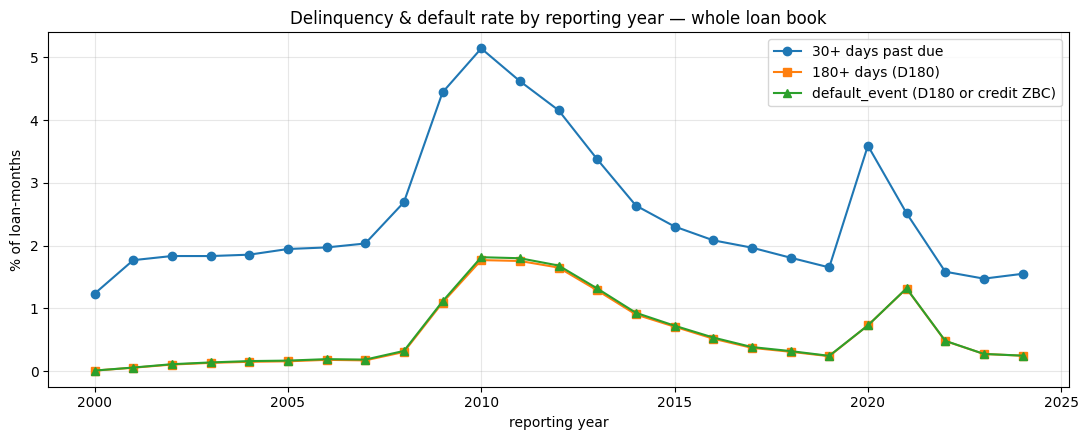

In [12]:
if dlq is not None:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(dlq.index, dlq["dpd30_plus_pct"], marker="o", label="30+ days past due")
    ax.plot(dlq.index, dlq["d180_plus_pct"], marker="s", label="180+ days (D180)")
    ax.plot(dlq.index, dlq["default_event_pct"], marker="^", label="default_event (D180 or credit ZBC)")
    ax.set_xlabel("reporting year")
    ax.set_ylabel("% of loan-months")
    ax.set_title("Delinquency & default rate by reporting year — whole loan book")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

,n_loans,n_ever_default,lifetime_default_pct
origination_year,,,
1999,6461,146,2.2597
2000,50751,1127,2.2206
2001,134997,2720,2.0149
2002,154400,3448,2.2332
2003,204103,6498,3.1837
2004,69787,4070,5.8320
2005,57860,5526,9.5506
2006,43386,5449,12.5594
2007,49896,7152,14.3338


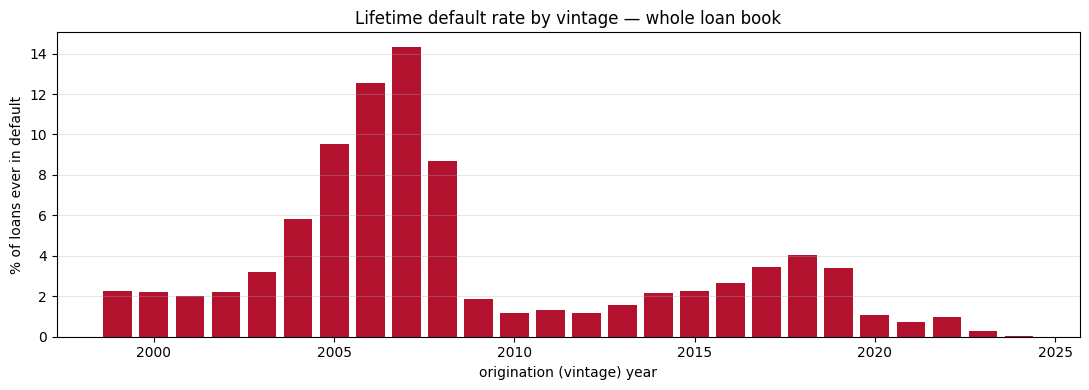

In [13]:
if PROFILE and PROFILE["vintage_default_by_origination_year"]:
    vint = pd.DataFrame(PROFILE["vintage_default_by_origination_year"]).set_index("origination_year")
    display(vint)
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(vint.index, vint["lifetime_default_pct"], color="#b3122f")
    ax.set_xlabel("origination (vintage) year")
    ax.set_ylabel("% of loans ever in default")
    ax.set_title("Lifetime default rate by vintage — whole loan book")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No vintage table (profile missing or built with --no-vintage).")

### 4d. Is the 4% sample representative? — 4% panel vs 100% book

The pretraining panel is a **deterministic 4% hash sample on `loan_id`** (whole loan histories kept
or dropped together). This section proves the sample reproduces the whole book's 26-year default
curve — including the 2008–2012 crisis and the 2020–2021 COVID spike — not just its average.

Generate the two delinquency profiles (each streams ~5 columns, so the full-book pass is cheap),
then re-run this notebook:

```bash
# 4% sample (your pretraining panel)
python scripts/profile_fannie_dataset.py \
    --panel gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet \
    --out reports/delinquency_4pct.json --delinquency-only

# 100% whole loan book, straight from the raw source
python scripts/profile_fannie_dataset.py \
    --raw-root gs://sriram-credit-fm-data/fannie_by_reporting \
    --out reports/delinquency_100pct.json --delinquency-only --no-vintage --no-loan-count
```

The **pooled** (loan-month-weighted) default rate is the robust headline; per-year gaps in thin
years (very low base rates) are just sampling noise. Note the panel stops at 2024 while the raw book
includes partial-2025, so part of any pooled gap is that **window mismatch**, not sampling bias.

In [14]:
DLQ_4PCT = ROOT / "reports" / "delinquency_4pct.json"
DLQ_100PCT = ROOT / "reports" / "delinquency_100pct.json"
if DLQ_4PCT.exists() and DLQ_100PCT.exists():
    CMP = importlib.util.spec_from_file_location("cmp", ROOT / "scripts" / "compare_profiles.py")
    cmp = importlib.util.module_from_spec(CMP)
    CMP.loader.exec_module(cmp)
    prof_4, prof_100 = json.loads(DLQ_4PCT.read_text()), json.loads(DLQ_100PCT.read_text())
    LA, LB = "4% sample", "100% book"
    yt = cmp._year_table(prof_4, prof_100, LA, LB)
    pa, pb = cmp._pooled(prof_4), cmp._pooled(prof_100)
    rel = cmp._rel(pa["default_event_pct"], pb["default_event_pct"])
    verdict = "REPRESENTATIVE" if (rel is not None and abs(rel) <= 5.0) else "REVIEW"
    print(f"{LA}: {prof_4['n_rows']:,} rows   {LB}: {prof_100['n_rows']:,} rows")
    print(f"pooled default rate — {LA}: {pa['default_event_pct']}%   {LB}: {pb['default_event_pct']}%"
          f"   (Δ {round(pa['default_event_pct'] - pb['default_event_pct'], 4)} pp, {rel}% rel)")
    print(f"VERDICT: {verdict}  (pooled |rel| <= 5%)")
    display(yt[[f"default_event_pct__{LA}", f"default_event_pct__{LB}",
                "default_event_pct__diff_pp", "default_event_pct__diff_rel%"]])
else:
    yt = None
    print("Provide reports/delinquency_4pct.json and reports/delinquency_100pct.json "
          "(see the commands above) to activate this comparison.")

4% sample: 125,027,505 rows   100% book: 3,314,483,004 rows
pooled default rate — 4% sample: 0.6708%   100% book: 0.6481%   (Δ 0.0227 pp, 3.503% rel)
VERDICT: REPRESENTATIVE  (pooled |rel| <= 5%)


,default_event_pct__4% sample,default_event_pct__100% book,default_event_pct__diff_pp,default_event_pct__diff_rel%
year,,,,
2000,0.0114,0.0143,-0.0029,-20.280
2001,0.0595,0.0668,-0.0073,-10.928
2002,0.1128,0.1105,0.0023,2.081
2003,0.1409,0.1389,0.0020,1.440
2004,0.1624,0.1589,0.0035,2.203
2005,0.1700,0.1717,-0.0017,-0.990
2006,0.1934,0.1974,-0.0040,-2.026
2007,0.1860,0.1914,-0.0054,-2.821
2008,0.3241,0.3272,-0.0031,-0.947


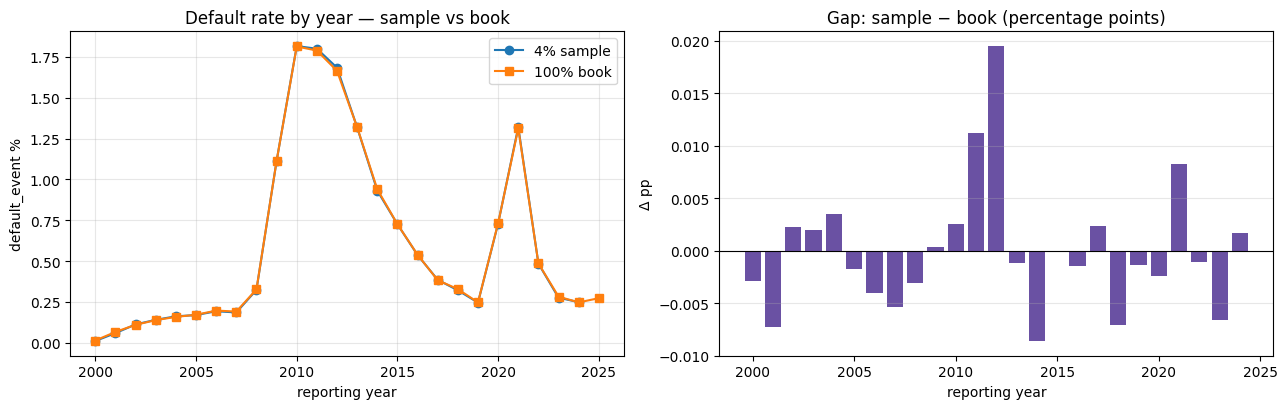

In [15]:
if yt is not None:
    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
    yr = yt.index
    ax1.plot(yr, yt["default_event_pct__4% sample"], marker="o", label="4% sample")
    ax1.plot(yr, yt["default_event_pct__100% book"], marker="s", label="100% book")
    ax1.set_title("Default rate by year — sample vs book")
    ax1.set_xlabel("reporting year")
    ax1.set_ylabel("default_event %")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax2.bar(yr, yt["default_event_pct__diff_pp"], color="#6a51a3")
    ax2.axhline(0, color="k", lw=0.8)
    ax2.set_title("Gap: sample − book (percentage points)")
    ax2.set_xlabel("reporting year")
    ax2.set_ylabel("Δ pp")
    ax2.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Per-column statistics

Computed by `scripts/profile_fannie_dataset.py` in a single memory-bounded streaming pass over the
dataset. Numeric columns report min/mean/std and quantiles (quantiles from a 200k reservoir sample);
categorical columns report their top values; distinct counts are exact up to a 200k cap.

**These tables need the *full* profile** (with per-column stats), not a delinquency-only one. If the
cells below are empty, generate it once (a few minutes on the 4% panel) and re-run this notebook:

```bash
python scripts/profile_fannie_dataset.py \
    --panel gs://sriram-credit-fm-data/output/raw/fannie_mae/panel_2000_2024.parquet \
    --out reports/fannie_dataset_profile.json
```

In [16]:
def stats_frames(profile):
    numeric, categ = [], []
    for name, s in profile["columns"].items():
        base = {"column": name, "n": s["n"], "nulls": s["nulls"], "null_%": s["null_pct"],
                "n_unique": s["n_unique"]}
        if s["kind"] == "numeric" and s.get("numeric"):
            numeric.append({**base, **s["numeric"]})
        else:
            top = s.get("top_values") or []
            base["min"], base["max"] = s.get("min"), s.get("max")
            base["top_values"] = ", ".join(f"{v}={p}%" for v, c, p in top[:6])
            categ.append(base)
    return (pd.DataFrame(numeric).set_index("column") if numeric else pd.DataFrame(),
            pd.DataFrame(categ).set_index("column") if categ else pd.DataFrame())

if HAS_COLUMN_STATS:
    NUM, CAT = stats_frames(PROFILE)
    print(f"{len(NUM)} numeric + {len(CAT)} categorical/date columns profiled")
else:
    NUM = CAT = pd.DataFrame()
    print("Loaded profile has no per-column stats (delinquency-only). "
          "Generate the full profile above, then re-run — sections 5a-5c will populate.")

33 numeric + 85 categorical/date columns profiled


### 5a. Numeric columns

In [17]:
NUM if not NUM.empty else 'no per-column stats — generate the full profile (see above)'

,n,nulls,null_%,n_unique,min,max,mean,std,p1,p25,median,p75,p99
column,,,,,,,,,,,,,
original_interest_rate,125027277,228,0.0002,4354,1.625,16.50,4.762597,1.309790,2.3750,3.7500,4.750,5.7500,7.8750
current_interest_rate,123387658,1639847,1.3116,4357,0.000,12.20,4.730905,1.309411,2.3750,3.6250,4.625,5.7500,7.8750
original_upb,125027505,0,0.0000,1126,3000.000,2095000.00,195973.106118,118664.275807,38000.0000,108000.0000,167000.000,256000.0000,584000.0000
current_actual_upb,125027505,0,0.0000,">200,000",0.000,2095000.00,156221.442464,121678.728585,0.0000,69650.9200,130788.375,218955.0300,542000.0000
original_loan_term,125027505,0,0.0000,268,60.000,360.00,305.791560,82.503632,120.0000,180.0000,360.000,360.0000,360.0000
loan_age,123386299,1641206,1.3127,313,-2.000,310.00,45.557392,41.758240,0.0000,14.0000,33.000,65.0000,185.0000
remaining_months_to_legal_maturity,123379402,1648103,1.3182,485,0.000,562.00,262.278029,94.916843,37.0000,173.0000,304.000,340.0000,361.0000
remaining_months_to_maturity,121548662,3478843,2.7825,452,0.000,480.00,253.342758,97.655467,23.0000,167.0000,295.000,337.0000,359.0000
original_ltv,125027505,0,0.0000,97,1.000,97.00,69.677863,17.805566,21.0000,59.0000,75.000,80.0000,97.0000


### 5b. Categorical &amp; date columns (top values)

In [18]:
CAT if not CAT.empty else 'no per-column stats — generate the full profile (see above)'

,n,nulls,null_%,n_unique,min,max,top_values
column,,,,,,,
reference_pool_id,0,125027505,100.0000,0,None,None,
loan_id,125027505,0,0.0000,">200,000",000097473134,999999844838,"365774636735=0.0%, 860917506101=0.0%, 480893428361=0.0%, 958552219105=0.0%, 862716750411=0.0%, 5..."
monthly_reporting_period,125027505,0,0.0000,300,012000,122024,"082024=0.502%, 102024=0.502%, 092024=0.502%, 072024=0.502%, 102023=0.502%, 122023=0.502%"
channel,125027505,0,0.0000,3,B,R,"R=54.127%, C=31.9%, B=13.972%"
seller_name,125026533,972,0.0008,191,Academy Mortgage Corporation,"loanDepot.com, LLC","Other=37.909%, Wells Fargo Bank, N.A.=10.535%, Bank Of America, N.A.=9.194%, Jpmorgan Chase Bank..."
servicer_name,122105381,2922124,2.3372,329,1st State Bank,"loanDepot.com, LLC","Other=33.591%, Wells Fargo Bank, N.A.=11.714%, Bank Of America, N.A.=8.673%, Jpmorgan Chase Bank..."
master_servicer,0,125027505,100.0000,0,None,None,
upb_at_issuance,0,125027505,100.0000,0,None,None,
origination_date,125027505,0,0.0000,312,1999-01-31,2024-12-31,"2003-07-31=1.859%, 2003-06-30=1.617%, 2003-04-30=1.547%, 2003-05-31=1.406%, 2003-08-31=1.299%, 2..."


### 5c. Missingness — most-null columns

,null_%
column,
reference_pool_id,100.0
repurchase_date,100.0
loan_holdback_effective_date,100.0
loan_holdback_indicator,100.0
zero_balance_code_change_date,100.0
cumulative_credit_event_net_gain_or_loss,100.0
current_period_credit_event_net_gain_or_loss,100.0
cumulative_modification_loss_amount,100.0
current_period_modification_loss_amount,100.0


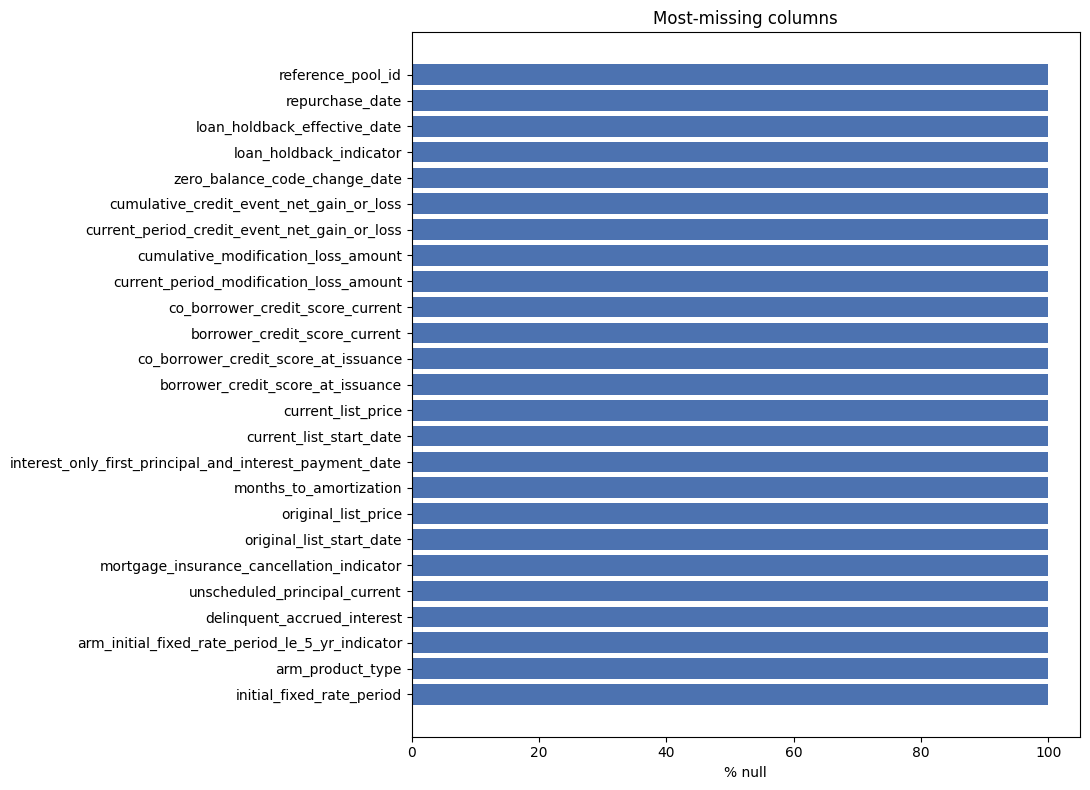

In [19]:
if PROFILE and PROFILE["columns"]:
    miss = pd.DataFrame([{"column": n, "null_%": s["null_pct"]}
                         for n, s in PROFILE["columns"].items()])
    miss = miss.sort_values("null_%", ascending=False).set_index("column")
    display(miss.head(30))
    import matplotlib.pyplot as plt
    top = miss[miss["null_%"] > 0].head(25)
    if not top.empty:
        fig, ax = plt.subplots(figsize=(11, max(3, 0.32 * len(top))))
        ax.barh(top.index[::-1], top["null_%"][::-1], color="#4c72b0")
        ax.set_xlabel("% null")
        ax.set_title("Most-missing columns")
        plt.tight_layout()
        plt.show()

## 6. Notes &amp; caveats

* **Sampling & representativeness.** The default profile runs on the ingested **4% panel**, a
  *deterministic hash sample on `loan_id`* — whole loan histories are kept or dropped together, so
  observed rates are **unbiased estimates** of the whole book. Point `--raw-root` at the raw source
  for exact whole-book numbers.
* **Label definition.** `default_event = (dlq_num >= 6, i.e. D180) OR zero_balance_code ∈
  {02, 03, 09, 15}`. `is_performing` gates the task to loans current at the observation date so the
  model predicts **new** defaults, not ones already in progress.
* **Leakage discipline.** Section 3c columns are never features. Splits are **by `loan_id`** (never
  by row) and temporal by **origination date** — see `docs/data/fannie_mae.md` and the decision log.
* **Unknown delinquency.** `current_loan_delinquency_status = 'XX'` (or blank after removal) becomes
  `dlq_num = <NA>`; every downstream consumer resolves it with `.fillna(False)`.
* **Field availability drifts over time.** Some fields are populated only after certain releases
  (e.g. `*_classic_fico` from Dec-2025, several loss/servicing fields post-2020) — high null % on
  those columns is expected, not a data error.